# Tech Challenge — Fase 4
## Etapa 2: Desenvolvimento do Modelo LSTM

Este notebook cobre o **ponto 2** do desafio: construir, treinar e avaliar uma
rede neural **LSTM** para prever o preço de fechamento das ações.

Pré-requisito: ter executado o notebook da **Etapa 1**, que gerou os artefatos
na pasta `artifacts/` (`X_train.npy`, `y_train.npy`, `X_valid.npy`, `y_valid.npy`,
`scaler.pkl`, `meta.pkl`).

Fluxo:
1. Carregar os artefatos da Etapa 1
2. Construir a arquitetura LSTM (Keras/TensorFlow)
3. Treinar com callbacks (EarlyStopping + ReduceLROnPlateau)
4. Avaliar com MAE, RMSE e MAPE (na escala real de preço)
5. Visualizar previsto vs. real e a curva de loss
6. Salvar o modelo treinado (Etapa 3)


## 0. Instalação e imports

A LSTM aqui usa TensorFlow/Keras. Descomente a instalação se necessário.

In [11]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## 1. Reprodutibilidade

In [12]:
# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

ARTIFACTS_DIR = "artifacts"
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 2. Carregar os Artefatos da Etapa 1

Recuperamos os arrays já janelados, o scaler e os metadados.

In [13]:
meta = joblib.load(os.path.join(ARTIFACTS_DIR, "meta.pkl"))
SYMBOL      = meta["symbol"]
WINDOW_SIZE = meta["window_size"]
TRAIN_RATIO = meta["train_ratio"]

df = pd.read_csv(os.path.join(ARTIFACTS_DIR, f"{SYMBOL}_clean.csv"),
                 index_col=0, parse_dates=True)
prices = df["Close"].astype(float).values
dates  = df.index

print(f"Símbolo: {SYMBOL} | Janela: {WINDOW_SIZE} | Amostras de preço: {len(prices)}")

Símbolo: AAPL | Janela: 60 | Amostras de preço: 2127


3. Alvo = Log-retorno, Split, Escalonamento e Janelas

Log-retorno: r_t = ln(P_t / P_{t-1}) — série aproximadamente estacionária e centrada em zero.
Split temporal mantém a proporção da Etapa 1, sem embaralhar.
StandardScaler ajustado só no treino (sem leakage).
Para cada janela guardamos base_price (P_{k-1}) e true_price (P_k) para reconstruir o preço na avaliação.

In [14]:
# 1) Log-retornos
log_prices = np.log(prices)
returns = np.diff(log_prices)                 # returns[i] = logP[i+1] - logP[i]

# 2) Split temporal
split_price_idx = int(len(prices) * TRAIN_RATIO)
split_ret_idx   = split_price_idx - 1         # fronteira treino/val na série de retornos

# 3) Scaler ajustado SÓ no treino
ret_scaler = StandardScaler()
ret_scaler.fit(returns[:split_ret_idx].reshape(-1, 1))
returns_scaled = ret_scaler.transform(returns.reshape(-1, 1)).flatten()

# 4) Janelas: prever o retorno do dia k a partir dos WINDOW retornos anteriores
def make_windows(k_start, k_end):
    X, y, base_price, true_price = [], [], [], []
    for k in range(k_start, k_end):
        if k - 1 - WINDOW_SIZE < 0:
            continue
        X.append(returns_scaled[k - 1 - WINDOW_SIZE : k - 1])
        y.append(returns_scaled[k - 1])
        base_price.append(prices[k - 1])
        true_price.append(prices[k])
    X = np.array(X).reshape(-1, WINDOW_SIZE, 1)
    return X, np.array(y), np.array(base_price), np.array(true_price)

X_train, y_train, _, _                   = make_windows(WINDOW_SIZE + 1, split_price_idx)
X_valid, y_valid, base_valid, true_valid = make_windows(split_price_idx, len(prices))
valid_dates = dates[-len(true_valid):]

print("X_train:", X_train.shape, "| X_valid:", X_valid.shape)

X_train: (1640, 60, 1) | X_valid: (426, 60, 1)




## 4. Arquitetura LSTM
Mesma arquitetura empilhada; agora a saída é o retorno escalonado (não o preço). Última camada linear.

In [15]:
def build_model(window_size, n_features=1, units=(64, 32), dropout=0.2, lr=1e-3):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(units[0], return_sequences=True),
        Dropout(dropout),
        LSTM(units[1], return_sequences=False),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(1),                       # retorno previsto (escala do StandardScaler)
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="mean_squared_error", metrics=["mae"])
    return model

## 5. Funções de Avaliação em Escala de Preço
Métricas medidas em preço reconstruído (não em retorno). Reconstrução one-step-ahead: P̂_k = P_{k-1} · exp(retorno_previsto).

In [ ]:
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def price_from_returns(pred_scaled, base_price):
    pred_ret = ret_scaler.inverse_transform(
        np.asarray(pred_scaled).reshape(-1, 1)).flatten()
    return base_price * np.exp(pred_ret)

def eval_price(model):
    pred_scaled = model.predict(X_valid, verbose=0).flatten()
    y_pred = price_from_returns(pred_scaled, base_valid)
    metrics = {
        "MAE":  mean_absolute_error(true_valid, y_pred),
        "RMSE": root_mean_squared_error(true_valid, y_pred),
        "MAPE": safe_mape(true_valid, y_pred),
    }
    return metrics, y_pred, pred_scaled

# MAE/RMSE/MAPE em preço são dominados por P_{k-1}: mesmo prevendo retorno
# zero o erro fica ~1%. Os diagnósticos abaixo olham o retorno, que é o que
# a rede de fato prevê, e revelam se ela aprendeu algo além do nível.
def return_diagnostics(pred_scaled, y_scaled):
    pred_ret = ret_scaler.inverse_transform(
        np.asarray(pred_scaled).reshape(-1, 1)).flatten()
    true_ret = ret_scaler.inverse_transform(
        np.asarray(y_scaled).reshape(-1, 1)).flatten()

    mse_modelo = np.mean((true_ret - pred_ret) ** 2)
    mse_zero   = np.mean(true_ret ** 2)
    nao_nulo   = np.sign(true_ret) != 0

    return {
        "acuracia_direcional_%": float(
            (np.sign(pred_ret[nao_nulo]) == np.sign(true_ret[nao_nulo])).mean() * 100),
        "R2_vs_prever_zero": float(1 - mse_modelo / mse_zero),
        "correlacao_prev_real": float(np.corrcoef(pred_ret, true_ret)[0, 1]),
        "razao_desvios_prev_real": float(pred_ret.std() / true_ret.std()),
        "previsoes_de_alta_%": float((pred_ret > 0).mean() * 100),
        "reais_de_alta_%": float((true_ret > 0).mean() * 100),
    }

## 6. Busca de Hiperparâmetros
Grade enxuta variando units, dropout e learning_rate. Cada config treinada com EarlyStopping; a melhor é escolhida pela menor val_loss. Atende ao requisito de ajuste de hiperparâmetros do ponto 2.

In [17]:
param_grid = [
    {"units": (64, 32), "dropout": 0.2, "lr": 1e-3},
    {"units": (32, 16), "dropout": 0.2, "lr": 1e-3},
    {"units": (64, 32), "dropout": 0.3, "lr": 5e-4},
    {"units": (96, 48), "dropout": 0.2, "lr": 1e-3},
]

SEARCH_EPOCHS = 40
resultados = []
for cfg in param_grid:
    tf.keras.utils.set_random_seed(SEED)
    m = build_model(WINDOW_SIZE, units=cfg["units"],
                    dropout=cfg["dropout"], lr=cfg["lr"])
    es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    h = m.fit(X_train, y_train, validation_data=(X_valid, y_valid),
              epochs=SEARCH_EPOCHS, batch_size=32, shuffle=False,
              callbacks=[es], verbose=0)
    val_loss = float(np.min(h.history["val_loss"]))
    price_metrics, _, _ = eval_price(m)
    resultados.append({**cfg, "val_loss": val_loss,
                       "RMSE_preco": price_metrics["RMSE"]})
    print(f"{cfg} -> val_loss {val_loss:.5f} | RMSE(preço) {price_metrics['RMSE']:.3f}")

resultados = pd.DataFrame(resultados).sort_values("val_loss").reset_index(drop=True)
melhor = resultados.iloc[0]
print("\nRanking:")
print(resultados)
print("\nMelhor config:", dict(melhor))

{'units': (64, 32), 'dropout': 0.2, 'lr': 0.001} -> val_loss 0.83568 | RMSE(preço) 4.044
{'units': (32, 16), 'dropout': 0.2, 'lr': 0.001} -> val_loss 0.83290 | RMSE(preço) 4.055
{'units': (64, 32), 'dropout': 0.3, 'lr': 0.0005} -> val_loss 0.83075 | RMSE(preço) 4.035
{'units': (96, 48), 'dropout': 0.2, 'lr': 0.001} -> val_loss 0.83044 | RMSE(preço) 4.045

Ranking:
      units  dropout      lr  val_loss  RMSE_preco
0  (96, 48)      0.2  0.0010  0.830441    4.044859
1  (64, 32)      0.3  0.0005  0.830754    4.034900
2  (32, 16)      0.2  0.0010  0.832899    4.055399
3  (64, 32)      0.2  0.0010  0.835684    4.044017

Melhor config: {'units': (96, 48), 'dropout': np.float64(0.2), 'lr': np.float64(0.001), 'val_loss': np.float64(0.8304414749145508), 'RMSE_preco': np.float64(4.044858944507018)}


## 7. Treino Final com a Melhor Configuração

In [18]:
tf.keras.utils.set_random_seed(SEED)
model = build_model(WINDOW_SIZE,
                    units=tuple(melhor["units"]),
                    dropout=float(melhor["dropout"]),
                    lr=float(melhor["lr"]))

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=100, batch_size=32, shuffle=False,
    callbacks=callbacks, verbose=1,
)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 1.0091 - mae: 0.7058 - val_loss: 0.8444 - val_mae: 0.6070 - learning_rate: 0.0010
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0089 - mae: 0.7058 - val_loss: 0.8436 - val_mae: 0.6062 - learning_rate: 0.0010
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.0065 - mae: 0.7053 - val_loss: 0.8405 - val_mae: 0.6085 - learning_rate: 0.0010
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.0091 - mae: 0.7075 - val_loss: 0.8445 - val_mae: 0.6087 - learning_rate: 0.0010
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.0027 - mae: 0.7042 - val_loss: 0.8422 - val_mae: 0.6091 - learning_rate: 0.0010
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.9930 - mae: 0.7039 - val_loss: 0.8395 - val_mae: 0.6103 - learning_rate: 0.0010
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.9949 - mae: 0.7036 - val_loss: 0.8378 - val_mae: 0.6111 - learning_rate: 0.0010
Epoch 

### 8. Avaliação Final vs. Baseline Naïve
Baseline naïve = random walk (retorno 0, preço de hoje = de ontem). A comparação é feita nas **três** métricas: escolher só a que favorece o modelo mascara o resultado — MAE, RMSE e MAPE podem discordar porque penalizam erros de formas diferentes.

Como reforço, a seção 8.1 mede o comportamento no espaço de **retorno**, onde a rede de fato opera. Em preço, o termo P_{k-1} domina a previsão e faz qualquer modelo parecer bom.

In [ ]:
metrics_lstm, y_pred, pred_scaled = eval_price(model)

y_naive = base_valid  # retorno previsto = 0
metrics_naive = {
    "MAE":  mean_absolute_error(true_valid, y_naive),
    "RMSE": root_mean_squared_error(true_valid, y_naive),
    "MAPE": safe_mape(true_valid, y_naive),
}

ganhos = {m: (1 - metrics_lstm[m] / metrics_naive[m]) * 100
          for m in ("MAE", "RMSE", "MAPE")}

tabela = pd.DataFrame({"LSTM (log-retorno)": metrics_lstm,
                       "Naïve (random walk)": metrics_naive,
                       "Ganho da LSTM (%)": ganhos}).T
print(tabela.round(4))

vence = [m for m, g in ganhos.items() if g > 0]
perde = [m for m in ganhos if m not in vence]

print()
if not perde:
    print(f"LSTM supera o random walk nas três métricas "
          f"(ganho de {min(ganhos.values()):.1f}% a {max(ganhos.values()):.1f}%).")
elif vence:
    print(f"Resultado misto: a LSTM supera o random walk em {', '.join(vence)} "
          f"e perde em {', '.join(perde)}.")
    print("Com ganhos abaixo de 1% a diferença é ruído, não vantagem preditiva.")
else:
    print("LSTM não supera o random walk em nenhuma das três métricas.")

                        MAE    RMSE    MAPE
LSTM (log-retorno)   2.8266  4.0449  1.1948
Naïve (random walk)  2.8098  4.0575  1.1862
Ganho da LSTM (%)   -0.5951  0.3123 -0.7213

Resultado misto: a LSTM supera o random walk em RMSE e perde em MAE, MAPE.
Com ganhos abaixo de 1% a diferença é ruído, não vantagem preditiva.


### 8.1 Diagnóstico no Espaço de Retorno
As métricas de preço não distinguem uma rede que aprendeu algo de uma que devolve sempre ~0. Estes quatro indicadores distinguem:

- **acurácia direcional** — % de acerto do sinal do retorno; 50% é o resultado de um chute.
- **R² vs. prever zero** — fração da variância do retorno explicada; ≤ 0 significa que prever zero seria melhor.
- **correlação previsto × real** — há sinal capturado, mesmo que pequeno?
- **razão de desvios** — quanto da volatilidade real a previsão reproduz. Valores baixos indicam encolhimento para a média, a resposta ótima em MSE quando não há sinal.

In [ ]:
diagnosticos = return_diagnostics(pred_scaled, y_valid)

for nome, valor in diagnosticos.items():
    print(f"{nome:26s} {valor:+9.4f}")

print("\nLeitura:")
if diagnosticos["acuracia_direcional_%"] < 50:
    print("- direção pior que um chute: o modelo erra o sinal mais do que acerta.")
else:
    print(f"- direção acima do acaso por "
          f"{diagnosticos['acuracia_direcional_%'] - 50:.2f} ponto(s) percentual(is).")

if diagnosticos["R2_vs_prever_zero"] <= 0:
    print("- R² não positivo: prever retorno zero seria melhor que a rede.")
else:
    print(f"- a rede explica {diagnosticos['R2_vs_prever_zero'] * 100:.1f}% "
          f"da variância do retorno.")

print(f"- a previsão reproduz {diagnosticos['razao_desvios_prev_real']:.0%} "
      f"da volatilidade real (encolhimento para a média).")

vies = (diagnosticos["previsoes_de_alta_%"] - diagnosticos["reais_de_alta_%"])
if abs(vies) > 10:
    print(f"- viés direcional de {vies:+.1f} p.p.: prevê alta em "
          f"{diagnosticos['previsoes_de_alta_%']:.1f}% dos dias contra "
          f"{diagnosticos['reais_de_alta_%']:.1f}% de altas reais.")

acuracia_direcional_%       +48.7059
R2_vs_prever_zero            +0.0191
correlacao_prev_real         +0.1510
razao_desvios_prev_real      +0.2176
previsoes_de_alta_%         +75.5869
reais_de_alta_%             +53.5211

Leitura:
- direção pior que um chute: o modelo erra o sinal mais do que acerta.
- a rede explica 1.9% da variância do retorno.
- a previsão reproduz 22% da volatilidade real (encolhimento para a média).
- viés direcional de +22.1 p.p.: prevê alta em 75.6% dos dias contra 53.5% de altas reais.


### 8.2 Real vs. Previsto vs. Naïve
As três curvas praticamente se sobrepõem — é o efeito esperado quando o retorno previsto é pequeno: o preço previsto acompanha o preço do dia anterior. O gráfico serve para mostrar que a LSTM **não** antecipa as viradas, e não como evidência de acerto.

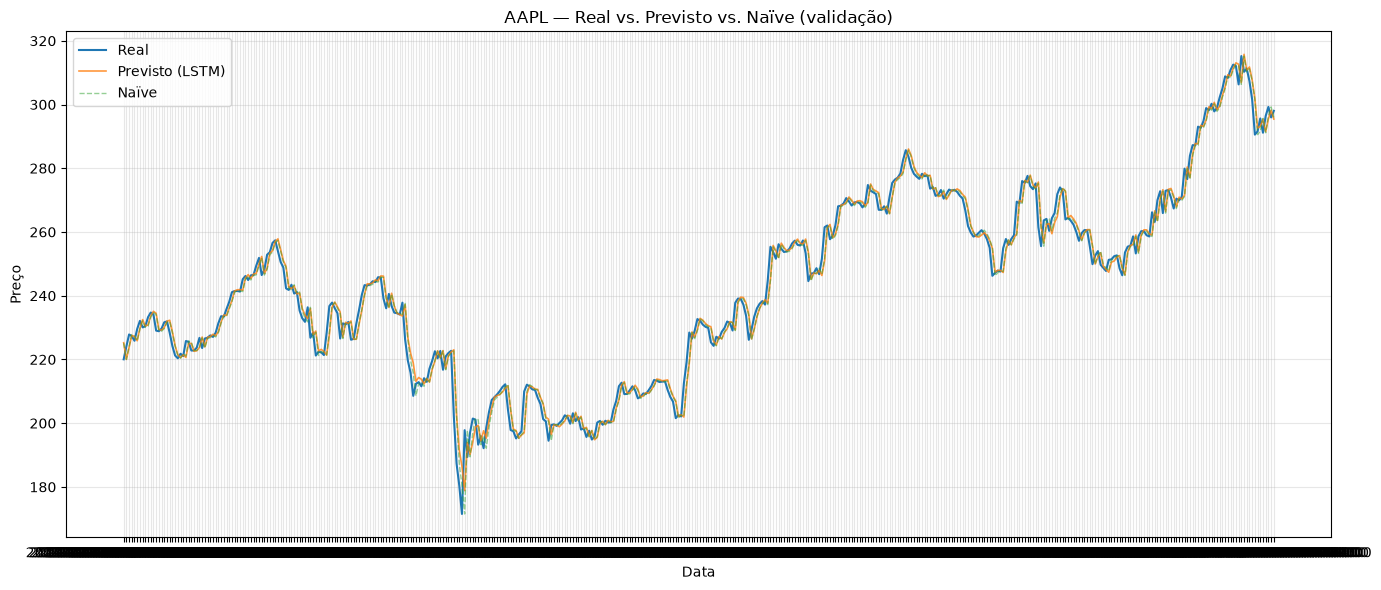

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(valid_dates, true_valid, label="Real", linewidth=1.5)
plt.plot(valid_dates, y_pred, label="Previsto (LSTM)", linewidth=1.2, alpha=0.8)
plt.plot(valid_dates, y_naive, label="Naïve", linewidth=1.0, alpha=0.5, linestyle="--")
plt.title(f"{SYMBOL} — Real vs. Previsto vs. Naïve (validação)")
plt.xlabel("Data"); plt.ylabel("Preço")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 8.3 Curva de Aprendizado (loss)

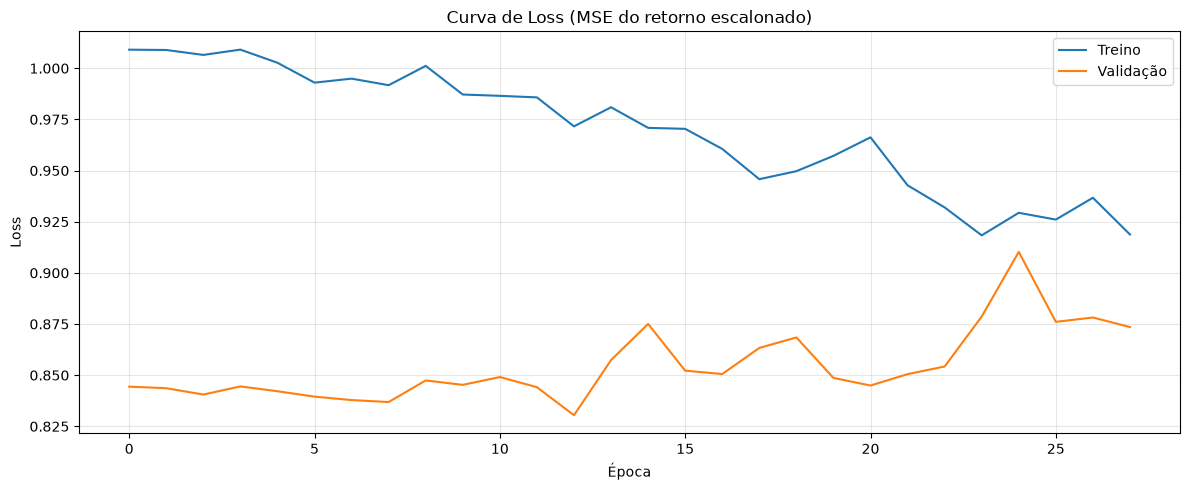

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Curva de Loss (MSE do retorno escalonado)")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Salvamento para Inferência (Etapa 3 — parcial)
Salvamento mínimo para a API da Etapa 4. Como o alvo é log-retorno, a inferência precisa do modelo, do ret_scaler e dos metadados (janela, símbolo, tipo de alvo, fórmula de reconstrução). O restore_best_weights=True já deixou os melhores pesos no model.

In [22]:
os.makedirs("models", exist_ok=True)

# Modelo treinado em formato .keras (carregável para inferência)
model.save("models/lstm_final.keras")

# Scaler dos retornos: a API usa para reverter o retorno previsto
joblib.dump(ret_scaler, os.path.join(ARTIFACTS_DIR, "ret_scaler.pkl"))

# Metadados que a API precisa junto do modelo
inference_meta = {
    "symbol": SYMBOL,
    "window_size": WINDOW_SIZE,
    "target": "log_return",                       # a rede prevê ln(P_t / P_{t-1})
    "reconstruction": "P_hat = P_prev * exp(pred_return)",
    "train_ratio": TRAIN_RATIO,
}
joblib.dump(inference_meta, os.path.join(ARTIFACTS_DIR, "inference_meta.pkl"))

# Métricas + melhores hiperparâmetros (rastreabilidade)
metrics = {
    "lstm": metrics_lstm,
    "naive_baseline": metrics_naive,
    "ganho_vs_naive_%": ganhos,
    "return_diagnostics": diagnosticos,
    "n_validacao": int(len(true_valid)),
    "best_hyperparams": {
        "units": tuple(melhor["units"]),
        "dropout": float(melhor["dropout"]),
        "lr": float(melhor["lr"]),
    },
}
joblib.dump(metrics, os.path.join(ARTIFACTS_DIR, "metrics.pkl"))

print("Salvos:")
print("  models/lstm_final.keras")
print("  artifacts/ret_scaler.pkl")
print("  artifacts/inference_meta.pkl")
print("  artifacts/metrics.pkl")

Salvos:
  models/lstm_final.keras
  artifacts/ret_scaler.pkl
  artifacts/inference_meta.pkl
  artifacts/metrics.pkl


## Conclusão da Etapa 2

Ponto 2 concluído (LSTM construída, hiperparâmetros ajustados por busca, treinada sobre log-retorno, avaliada em preço contra o random walk) e ponto 3 parcial (modelo + scaler + metadados salvos). Artefatos para a Etapa 4: `models/lstm_final.keras`, `artifacts/ret_scaler.pkl`, `artifacts/inference_meta.pkl`, `artifacts/metrics.pkl`.

**O que os números dizem.** A LSTM fica tecnicamente empatada com o random walk: ganha em RMSE por 0,3% e perde em MAE e MAPE por margem parecida. Diferenças dessa ordem em 426 dias de validação são ruído — não sustentam a afirmação de que o modelo é melhor.

Os diagnósticos de retorno explicam o empate. A rede reproduz apenas ~22% da volatilidade real e prevê alta em 76% dos dias, contra 54% de altas de fato: ela aprendeu o viés de alta do período e encolheu a magnitude para minimizar o MSE. O resultado é uma acurácia direcional de 48,7%, **abaixo** do acaso, apesar de um R² de +1,9% e correlação de +0,15 com o retorno real — há um fio de sinal na magnitude, insuficiente para virar vantagem prática.

**Por que isso é um resultado aceitável.** Preço diário de ação é próximo de um passeio aleatório; bater o naïve com uma LSTM univariada sobre a série de fechamento é improvável, e trabalhos que relatam o contrário quase sempre têm vazamento (escalonamento antes do split, ou métrica de preço sem baseline). Documentar o empate com o baseline explícito e os diagnósticos de retorno vale mais do que um MAPE de 1% apresentado isoladamente.

**Caminhos para melhorar** (fora do escopo desta entrega): features exógenas (volume, volatilidade realizada, indicadores técnicos, dados macro), alvo de horizonte mais longo onde a razão sinal/ruído é maior, ou trocar a regressão do retorno por classificação de direção com custo assimétrico.